In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata2 = sc.read_h5ad('GSE175533_sceasy_hay_onlyWT_redoUMAP_onlu_pstime_newSignScores.h5ad') 

In [4]:
adata2

AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm', 'pstime', 'senmayo', 'sasp', 'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
fromDave=pd.read_csv('hay_ps_data.txt', sep='\t', index_col=0)

In [6]:
fromDave

,PDL,pseudotime,dim1,dim2
barcode,,,,
AAACGGGAGAGAACAG-1,PDL_25,0.116258,4.023498,-4.674849
AAACGGGGTTTAAGCC-1,PDL_25,1.266756,4.259726,-5.553621
AAACGGGTCCTCATTA-1,PDL_25,4.245586,2.084356,-5.996397
AAACGGGTCTAAGCCA-1,PDL_25,18.990912,-1.842137,1.911255
AAAGATGCAGTGAGTG-1,PDL_25,12.590782,0.078292,0.377757
...,...,...,...,...
TTTCCTCTCACCCGAG-11,PDL_50,22.441066,-2.857130,5.152347
TTTCCTCTCCAGAAGG-11,PDL_50,21.823418,-3.480681,3.867586
TTTGCGCGTACAAGTA-11,PDL_50,22.441066,-3.093641,4.926021


In [8]:
adata2

AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm', 'pstime', 'senmayo', 'sasp', 'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'connectivities', 'distances'

In [9]:
adata2.obsm['X_umap']

array([[-2.261752  ,  1.1350595 ],
       [-1.9247773 , -0.7250318 ],
       [-0.44500402,  1.3132639 ],
       ...,
       [13.503501  ,  4.446233  ],
       [12.5454645 ,  4.0158315 ],
       [12.461073  ,  3.761379  ]], dtype=float32)

In [10]:
fromDave[['dim1', 'dim2']].to_numpy()

array([[ 4.02349768, -4.67484918],
       [ 4.25972567, -5.55362072],
       [ 2.08435641, -5.9963974 ],
       ...,
       [-3.0936407 ,  4.92602119],
       [-3.45327105,  4.23149976],
       [-2.52854814,  5.20375595]])

In [11]:
adata2.obs['pstime']=fromDave['pseudotime']

In [12]:
adata2

AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm', 'pstime', 'senmayo', 'sasp', 'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'connectivities', 'distances'

In [13]:
adata2.obsm['X_pstime']=fromDave[['dim1', 'dim2']]

In [14]:
adata2.obsm

AxisArrays with keys: X_mpcs, X_pca, X_rna_pcs_2kv, X_s_sct_pcs_s3_hay_d, X_umap, X_pstime

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


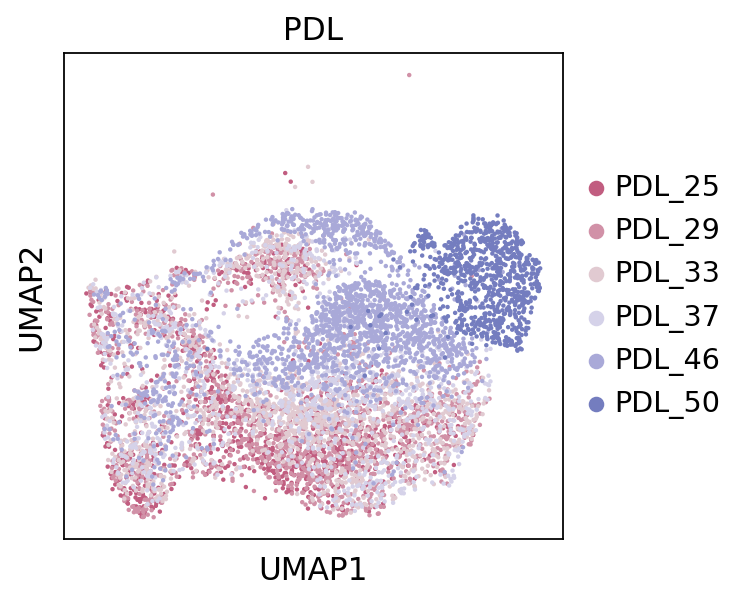

In [15]:
sc.pl.umap(adata2, color='PDL')

In [16]:
adata2.obsm['X_umap']=fromDave[['dim1', 'dim2']].values

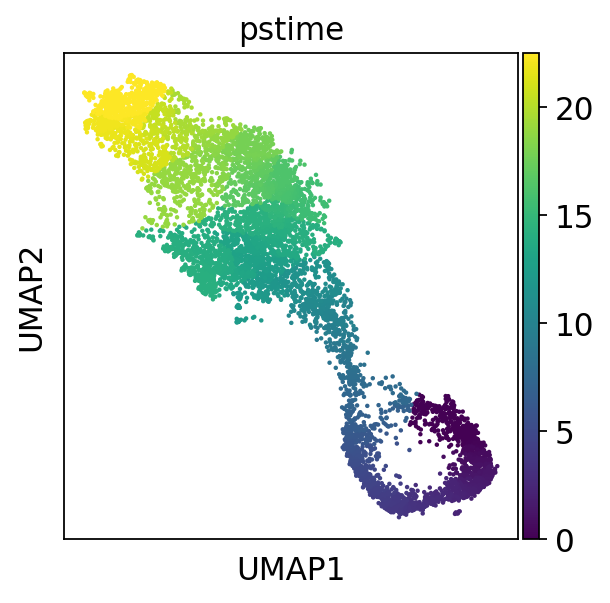

In [21]:
sc.pl.umap(adata2, color='pstime', save='Hayflick_pstime_UMAP_pstime.pdf')

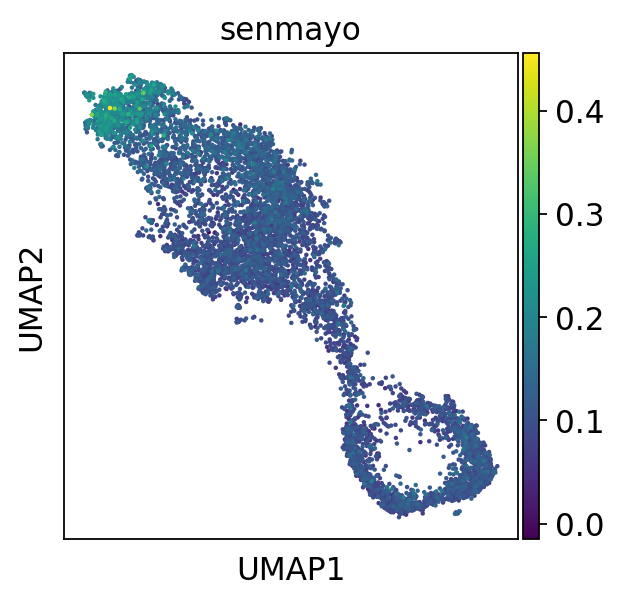

In [19]:
sc.pl.umap(adata2, color='senmayo')

In [20]:
adata2

AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm', 'pstime', 'senmayo', 'sasp', 'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap', 'X_pstime'
    obsp: 'connectivities', 'distances'

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


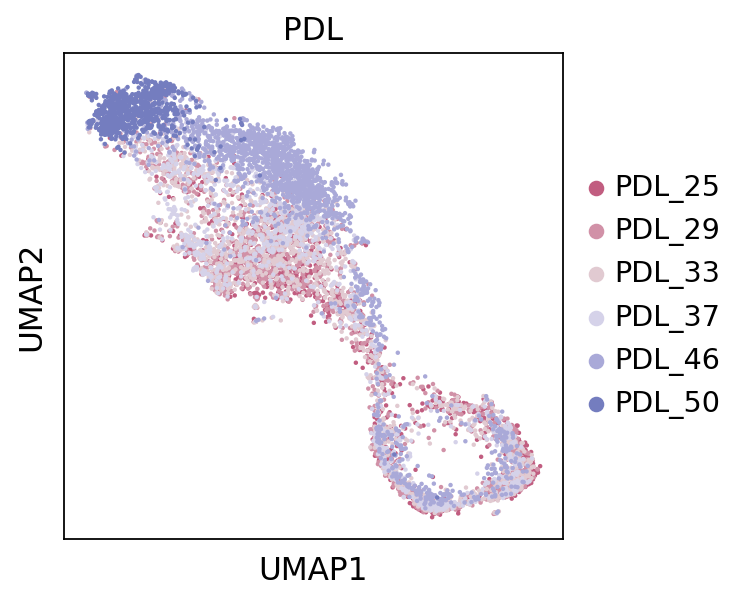

In [22]:
sc.pl.umap(adata2, color='PDL')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


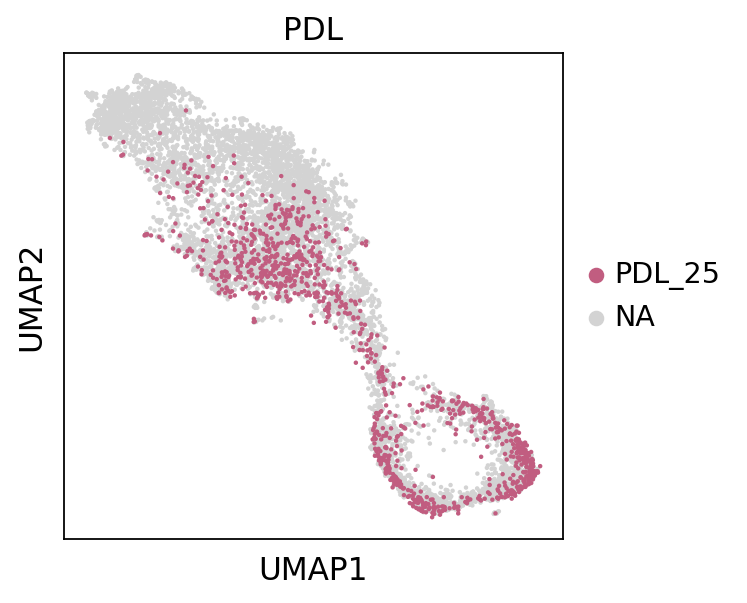

In [23]:
sc.pl.umap(adata2, color='PDL', groups='PDL_25')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


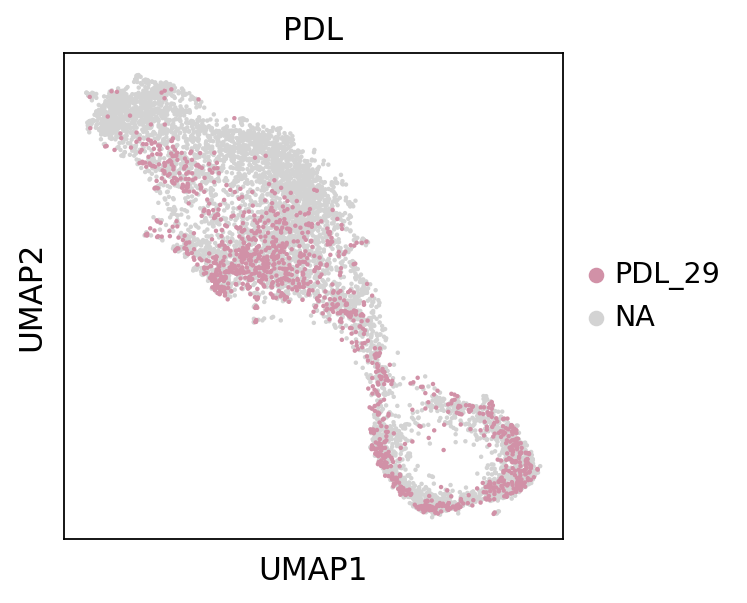

In [24]:
sc.pl.umap(adata2, color='PDL', groups='PDL_29')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


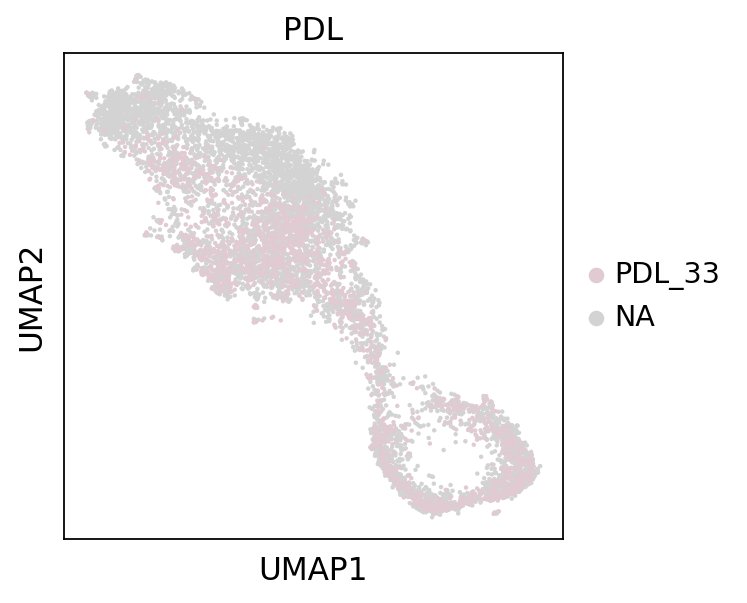

In [25]:
sc.pl.umap(adata2, color='PDL', groups='PDL_33')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


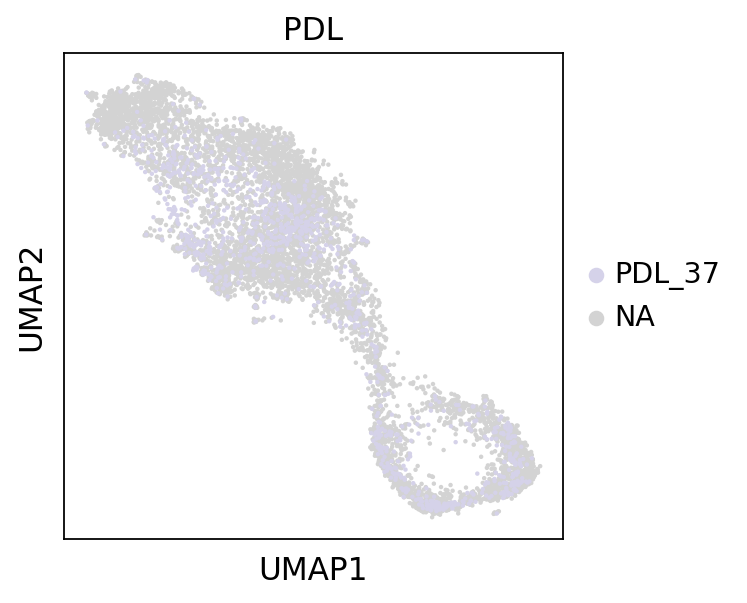

In [26]:
sc.pl.umap(adata2, color='PDL', groups='PDL_37')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


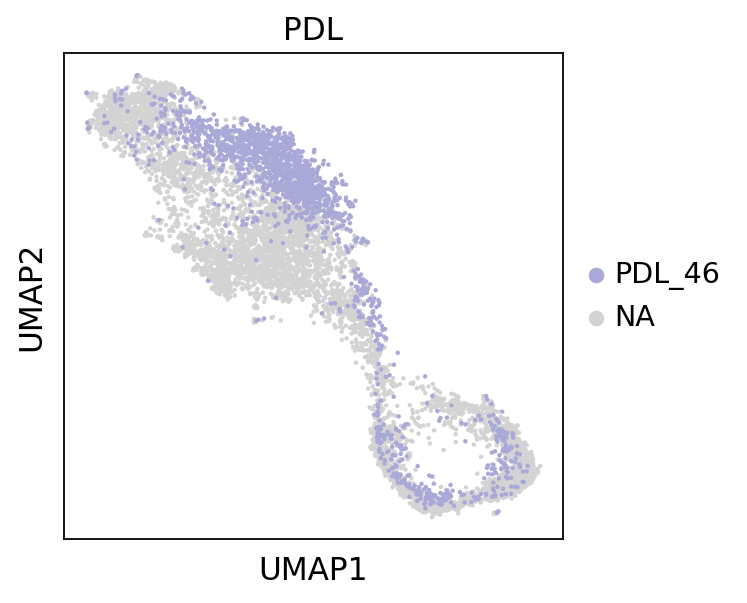

In [27]:
sc.pl.umap(adata2, color='PDL', groups='PDL_46')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


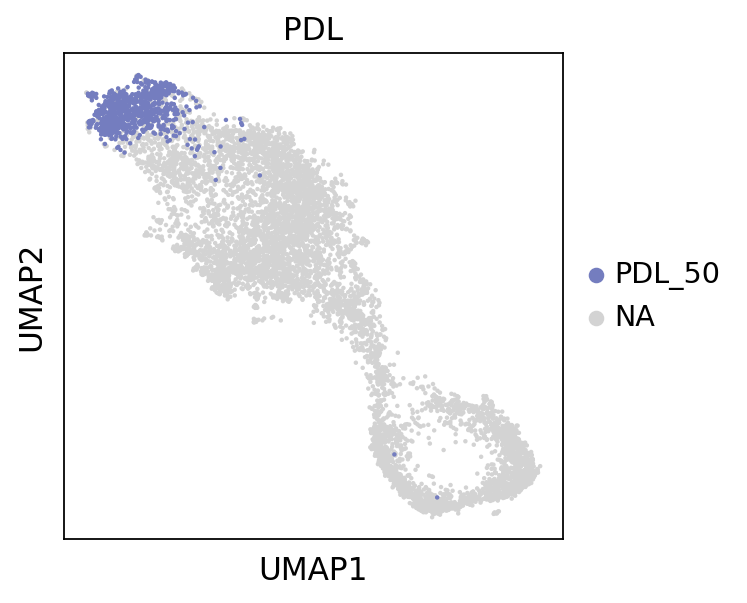

In [28]:
sc.pl.umap(adata2, color='PDL', groups='PDL_50')

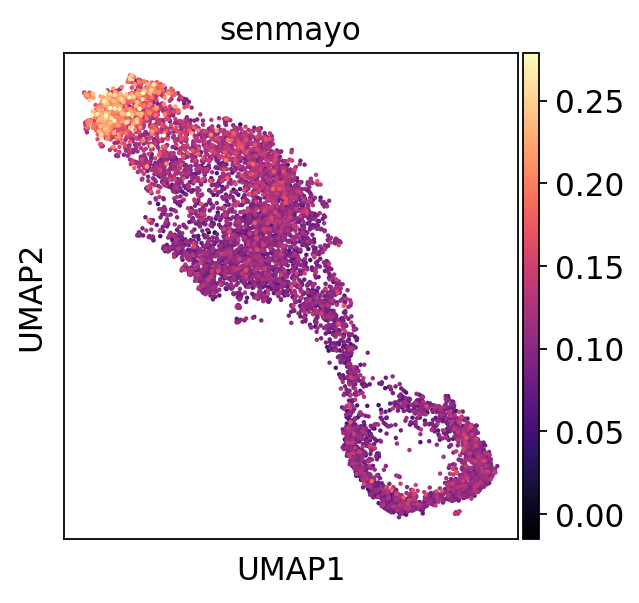

In [33]:
sc.pl.umap(adata2, color=['senmayo'], color_map='magma', vmax='p99.9', save='Hayflick_pstime_UMAP_senmayo_v99_9.pdf')

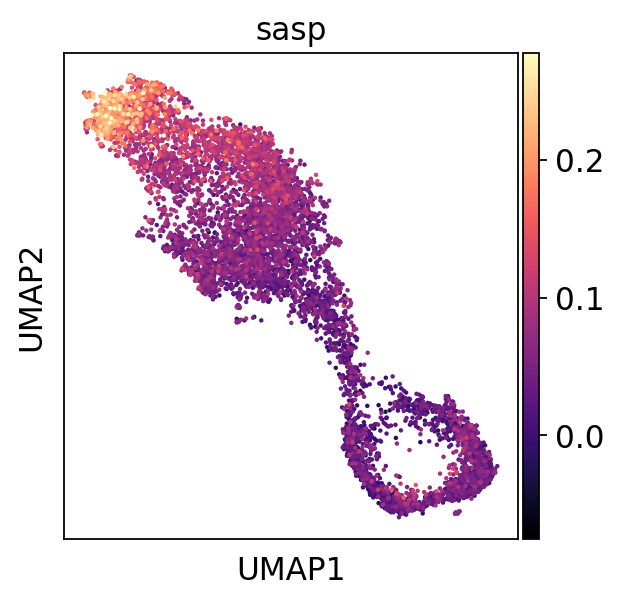

In [34]:
sc.pl.umap(adata2, color=['sasp'], color_map='magma', vmax='p99.9', save='Hayflick_pstime_UMAP_sasp_v99_9.pdf')

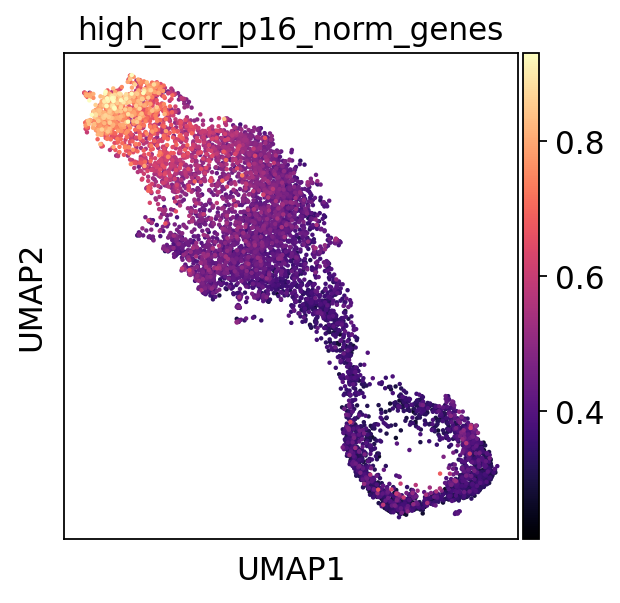

In [43]:
sc.pl.umap(adata2, color=['high_corr_p16_norm_genes'], color_map='magma', vmax='p99.9', save='Hayflick_pstime_UMAP_p16norm_top200corr_v99_9.pdf')

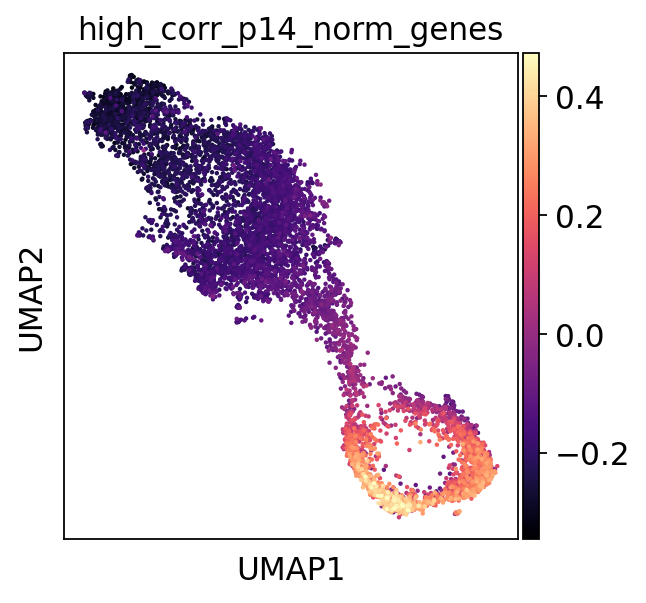

In [44]:
sc.pl.umap(adata2, color=['high_corr_p14_norm_genes'], color_map='magma', vmax='p99.9', save='Hayflick_pstime_UMAP_p14norm_top200corr_v99_9.pdf')

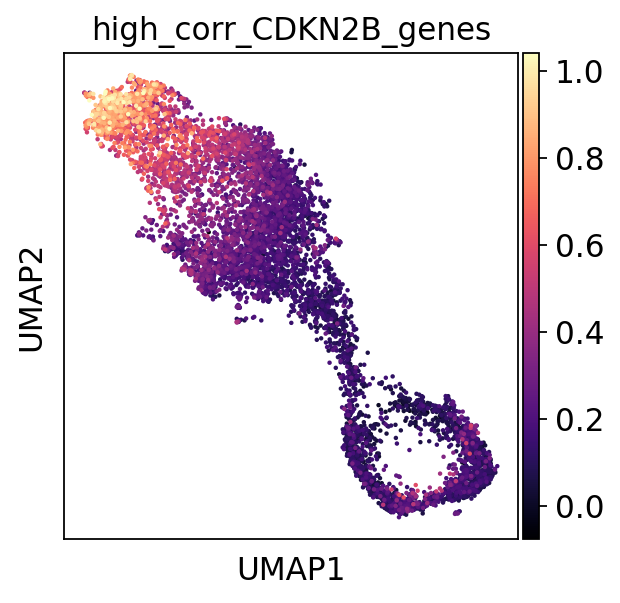

In [45]:
sc.pl.umap(adata2, color=['high_corr_CDKN2B_genes'], color_map='magma', vmax='p99.9', save='Hayflick_pstime_UMAP_p15_top200corr_v99_9.pdf')

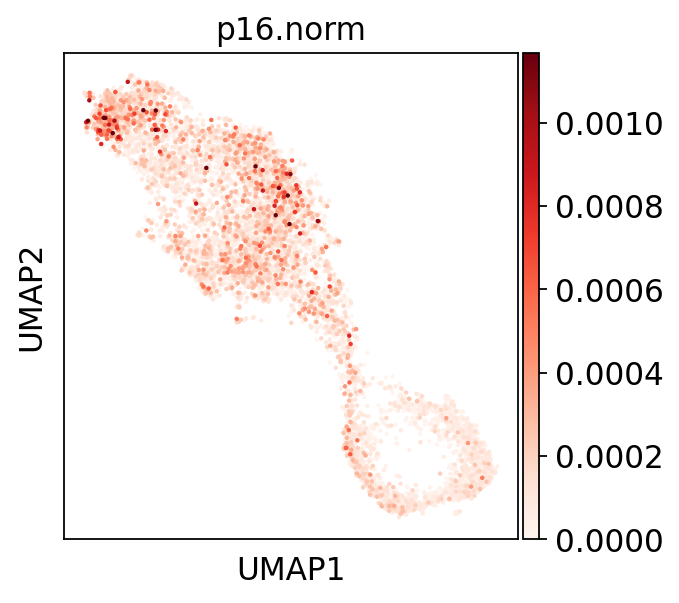

In [39]:
sc.pl.umap(adata2, color=['p16.norm'], color_map='Reds', vmax='p99.9', save='Hayflick_pstime_UMAP_p16norm_v99_9.pdf')

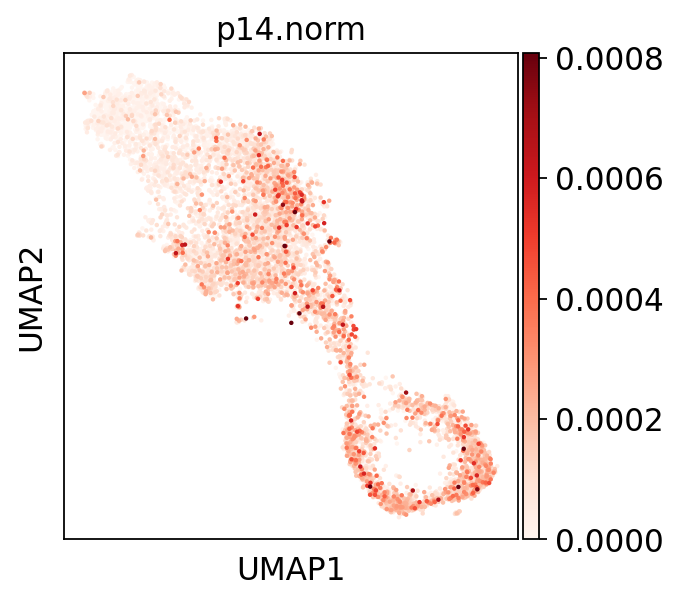

In [40]:
sc.pl.umap(adata2, color=['p14.norm'], color_map='Reds', vmax='p99.9', save='Hayflick_pstime_UMAP_p14norm_v99_9.pdf')

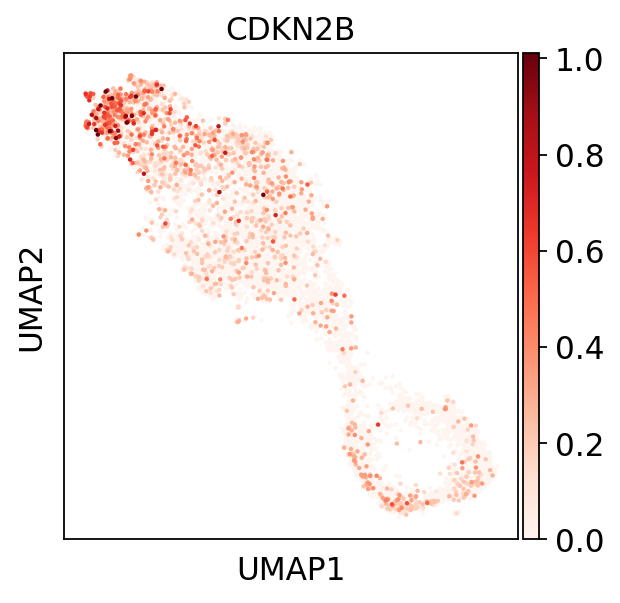

In [41]:
sc.pl.umap(adata2, color=['CDKN2B'], color_map='Reds', vmax='p99.9', save='Hayflick_pstime_UMAP_p15_v99_9.pdf')

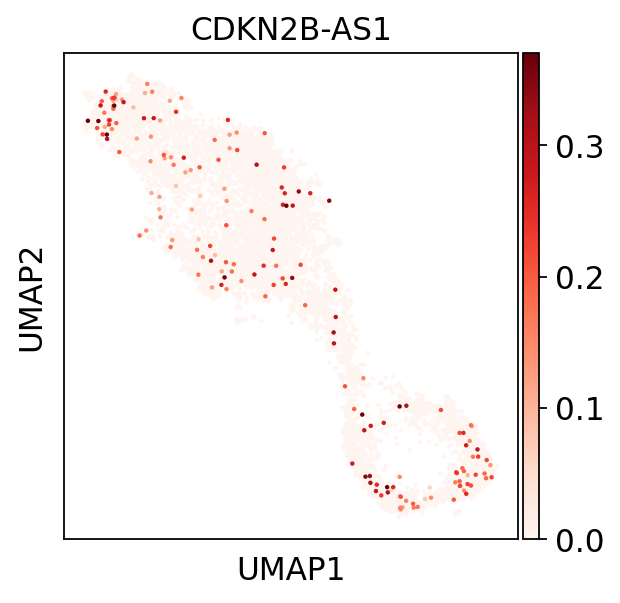

In [42]:
sc.pl.umap(adata2, color=['CDKN2B-AS1'], color_map='Reds', vmax='p99.9', save='Hayflick_pstime_UMAP_ANRIL_v99_9.pdf')

In [ ]:
sc.pl.umap(adata2, color=['p16'], color_map='Reds', vmax='p99.9')

In [ ]:
sc.pl.umap(adata2, color=['p14'], color_map='Reds', vmax='p99.9')

In [ ]:
sc.pl.umap(adata2, color=['senmayo', 'sasp'], color_map='magma', vmax='p99.9')

In [ ]:
sc.pl.umap(adata2, color=['p16.norm','p14.norm'], color_map='Reds', vmax='p99.75')

In [ ]:
sc.pl.umap(adata2, color=['CDKN2B','CDKN2B-AS1'], color_map='Reds', vmax='p99.75')

In [ ]:
sc.pl.umap(adata2, color=['MKI67','TOP2A'], color_map='magma', vmax='p99.75')

In [ ]:
adata2

In [ ]:
sc.pl.umap(adata2, color=['nCount_RNA','nFeature_RNA'], color_map='magma', vmax='p99.75')

In [ ]:
adata2.obs

In [46]:
col1, col2 = 'p16.norm', 'pstime'

corr = adata2.obs[col1].corr(adata2.obs[col2])
print("Correlation between ", col1, " and ", col2, "is: ", round(corr, 2))


Correlation between  p16.norm  and  pstime is:  0.25


In [47]:
col1, col2 = 'p14.norm', 'pstime'

corr = adata2.obs[col1].corr(adata2.obs[col2])
print("Correlation between ", col1, " and ", col2, "is: ", round(corr, 2))


Correlation between  p14.norm  and  pstime is:  -0.32


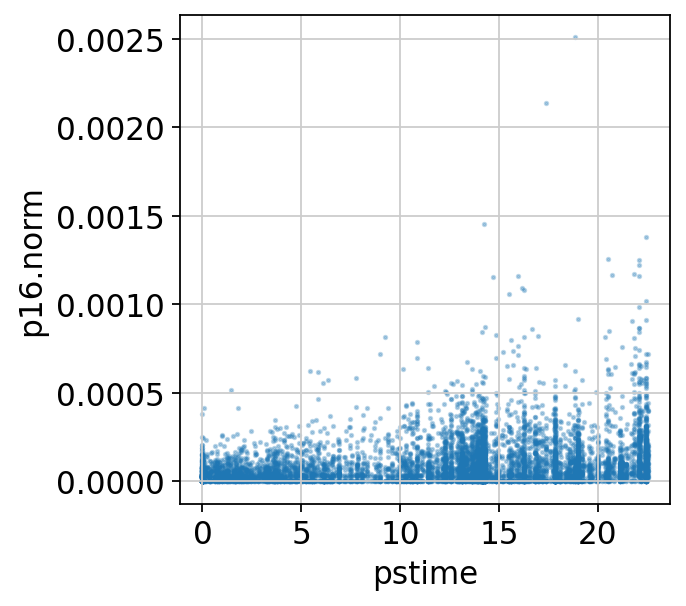

In [48]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 4.5, 4

scatter = adata2.obs.plot(y = 'p16.norm', x = 'pstime', kind='scatter', s=2, alpha=.3)
#scatter.set_xlim((0, 0.001))
plt.tight_layout() 
#plt.savefig("Chen_et_al_p16norm_pseudotime.pdf", format='pdf')

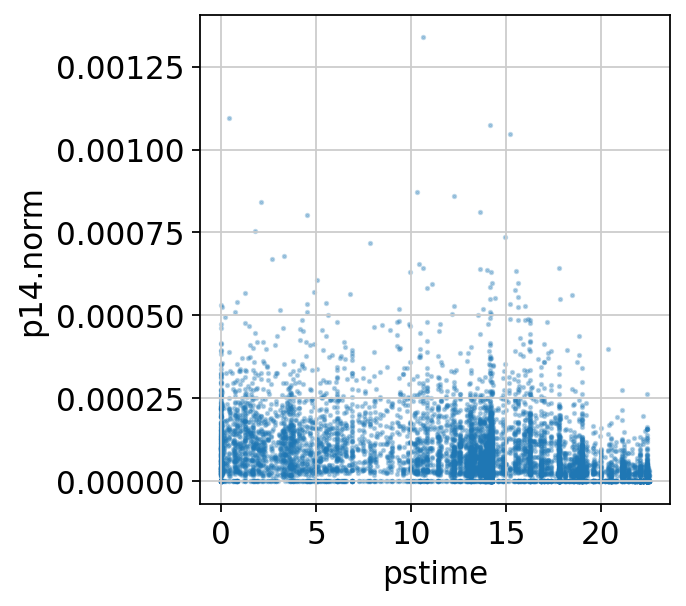

In [49]:
scatter = adata2.obs.plot(y = 'p14.norm', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
#plt.savefig("Chen_et_al_p14norm_pseudotime.pdf", format='pdf')

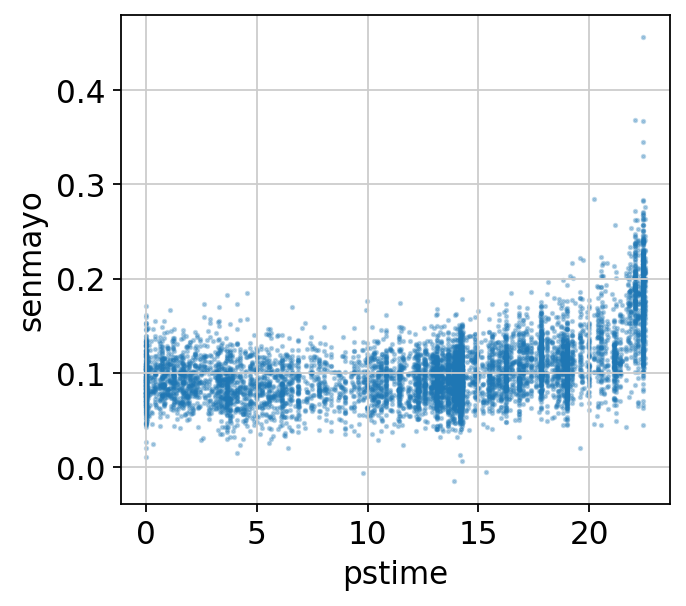

In [50]:
scatter = adata2.obs.plot(y = 'senmayo', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
#plt.savefig("Chen_et_al_senmayo_pseudotime.pdf", format='pdf')

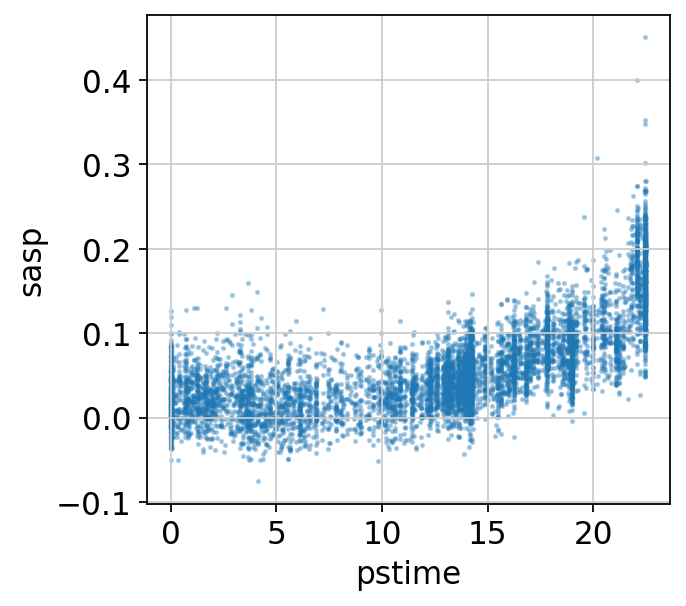

In [51]:
scatter = adata2.obs.plot(y = 'sasp', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
#plt.savefig("Chen_et_al_sasp_pseudotime.pdf", format='pdf')

In [ ]:
scatter = adata2.obs.plot(y = 'p16.norm', x = 'senmayo', kind='scatter', s=2, alpha=.3)


In [ ]:
scatter = adata2.obs.plot(y = 'p14.norm', x = 'senmayo', kind='scatter', s=2, alpha=.3)


In [ ]:
CDKN2B_top200=pd.read_csv('HVG_correlation_matrix_hayflick_CDKN2B_top201_pearson_corr_genes.txt', sep='\t', index_col=0)
CDKN2B_top200

In [ ]:
list(CDKN2B_top200.index)[1:]

In [ ]:
#sc.tl.score_genes(adata2, list(CDKN2B_top200.index)[1:], score_name='high_corr_CDKN2B_genes')
#sc.pl.umap(adata2, color=['high_corr_CDKN2B_genes' ], color_map='magma')

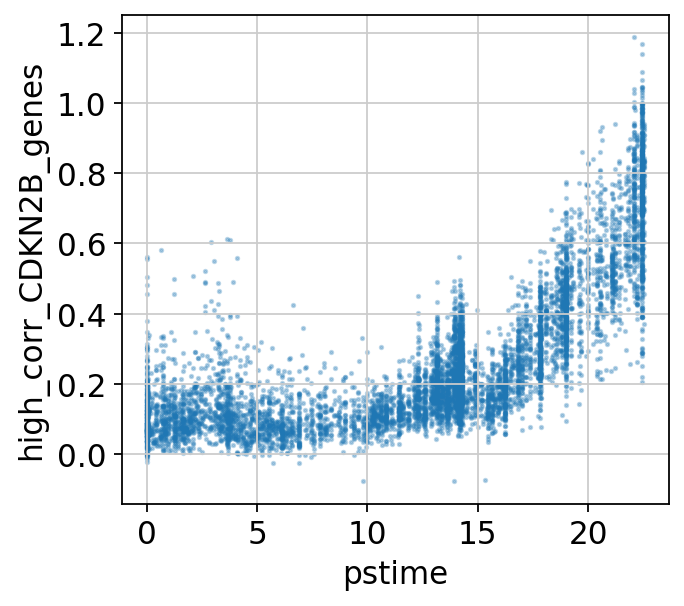

In [57]:
scatter = adata2.obs.plot(y = 'high_corr_CDKN2B_genes', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
plt.savefig("Chen_et_al_high_corr_CDKN2B_newSign_pseudotime.pdf", format='pdf')

In [ ]:
#p16_top200=pd.read_csv('HVG_correlation_matrix_hayflick_p16_norm_top200_pearson_corr_genes.txt', sep='\t', index_col=0)


In [ ]:
#p16_top200

In [ ]:
#sc.tl.score_genes(adata2, list(p16_top200.index), score_name='high_corr_p16_norm_genes')
#sc.pl.umap(adata2, color=['high_corr_p16_norm_genes' ], color_map='magma')


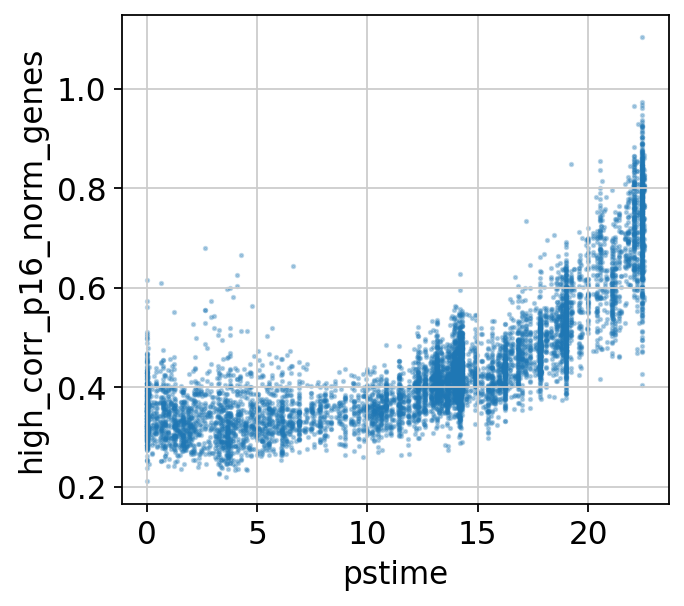

In [55]:
scatter = adata2.obs.plot(y = 'high_corr_p16_norm_genes', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
plt.savefig("Chen_et_al_high_corr_p16_norm_newSign_pseudotime.pdf", format='pdf')

In [ ]:
#p14_top200=pd.read_csv('HVG_correlation_matrix_hayflick_p14_norm_top200_pearson_corr_genes.txt', sep='\t', index_col=0)
#sc.tl.score_genes(adata2, list(p14_top200.index), score_name='high_corr_p14_norm_genes')
#sc.pl.umap(adata2, color=['high_corr_p14_norm_genes' ], color_map='magma')

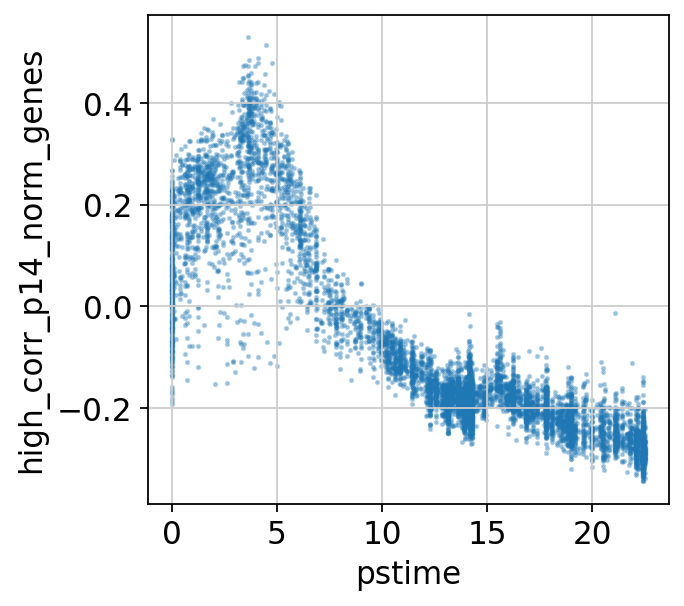

In [56]:
scatter = adata2.obs.plot(y = 'high_corr_p14_norm_genes', x = 'pstime', kind='scatter', s=2, alpha=.3)
plt.tight_layout() 
plt.savefig("Chen_et_al_high_corr_p14_norm_newSign_pseudotime.pdf", format='pdf')

In [ ]:
scatter = adata2.obs.plot(y = 'high_corr_p16_norm_genes', x = 'senmayo', kind='scatter', s=2, alpha=.3)


In [ ]:
scatter = adata2.obs.plot(y = 'high_corr_p14_norm_genes', x = 'senmayo', kind='scatter', s=2, alpha=.3)


In [ ]:
scatter = adata2.obs.plot(y = 'high_corr_p16_norm_genes', x = 'sasp', kind='scatter', s=2, alpha=.3)
scatter = adata2.obs.plot(y = 'high_corr_p14_norm_genes', x = 'sasp', kind='scatter', s=2, alpha=.3)


In [ ]:
scatter = adata2.obs.plot(y = 'senmayo', x = 'sasp', kind='scatter', s=2, alpha=.3)


In [ ]:
adata3 = adata2[adata2.obs['PDL'].isin(['PDL_46'])]


In [ ]:
scatter = adata3.obs.plot(y = 'high_corr_p16_norm_genes', x = 'pstime', kind='scatter', s=2, alpha=.3)


In [ ]:
adata3.obs

In [ ]:
col1, col2 = 'p16.norm', 'senmayo'

corr = adata3.obs[col1].corr(adata3.obs[col2])
print("Correlation between ", col1, " and ", col2, "is: ", round(corr, 2))


In [ ]:
col1, col2 = 'p16.norm', 'sasp'

corr = adata3.obs[col1].corr(adata3.obs[col2])
print("Correlation between ", col1, " and ", col2, "is: ", round(corr, 2))


In [ ]:
adata2

In [ ]:
sc.pl.umap(adata2, color=['IFNB1', 'IFNW1', 'IFNA21', 'IFNA4', 'IFNA16', 'IFNA7', 'IFNA17', 'IFNA14', 'IFNA5', 'KLHL9', 'IFNA6', 'IFNA13', 'IFNA2', 'IFNA8', 'IFNA1', 'IFNE'], color_map='Reds')